# Task 2 — Face Alignment: 01 Explore

**Goal.** Observation only: discover the on-disk data layout, sanity-check the arrays, look at the images, quantify the dominant sources of variability, and freeze a train/val split that every downstream notebook will load.

No modelling, no preprocessing functions, no feature extraction here. Artefacts produced:
- `data/data_layout.json` — single source of truth for paths/keys for notebooks 02–07.
- `data/split_indices.npz` — shared train/val indices.
- `figures/sample_grid.png`, `figures/mean_face.png` and variability histograms.

Lecture pointers used here are limited to W06_L12 (image basics) and W09_L18 (face alignment context — inter-eye normalisation, mean-face baseline). Modelling lectures (HOG, CNN, augmentation) are referenced in the closing notes-to-self cell only, to guide notebooks 02+.

In [1]:
import json
import os
from glob import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

plt.rcParams['font.size'] = 11
plt.rcParams['savefig.dpi'] = 150

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent if NB_DIR.name == 'task2_cv' else NB_DIR
DATA_DIR_CANDIDATES = [NB_DIR / 'data', REPO_ROOT / 'data', NB_DIR.parent / 'data']
FIG_DIR = NB_DIR / 'figures'
OUT_DATA_DIR = NB_DIR / 'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.exists()), DATA_DIR_CANDIDATES[0])
print(f'Notebook dir: {NB_DIR}')
print(f'Data dir:     {DATA_DIR}  (exists={DATA_DIR.exists()})')

Notebook dir: /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv
Data dir:     /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/data  (exists=True)


## 1. Discover the data layout

List every file in `data/`, print sizes, and for `.npz`/`.npy` files print array names + shapes. The brief (Table 2) names the files `face_alignment_{training,validation,test}_data.npz`, but we don't hard-code: we scan, match flexibly (spaces or underscores, any case), and record what we actually find.

In [2]:
def human_size(n):
    for unit in ['B', 'KB', 'MB', 'GB']:
        if n < 1024:
            return f'{n:.1f} {unit}'
        n /= 1024
    return f'{n:.1f} TB'

if not DATA_DIR.exists():
    print(f'!! {DATA_DIR} not found. Download face_alignment_{{training,validation,test}}_data.npz from the brief link and place them there.')
    listing = []
else:
    listing = sorted(p for p in DATA_DIR.iterdir() if p.is_file())
    for p in listing:
        print(f'{p.name:55s} {human_size(p.stat().st_size):>10s}')

for p in listing:
    if p.suffix.lower() == '.npz':
        try:
            with np.load(p, allow_pickle=True) as z:
                print(f'\n{p.name} keys:')
                for k in z.files:
                    arr = z[k]
                    print(f'  {k:20s} shape={arr.shape} dtype={arr.dtype}')
        except Exception as e:
            print(f'{p.name}: could not open ({e})')
    elif p.suffix.lower() == '.npy':
        try:
            arr = np.load(p, allow_pickle=True)
            print(f'{p.name}: shape={arr.shape} dtype={arr.dtype}')
        except Exception as e:
            print(f'{p.name}: could not open ({e})')

face_alignment_test_data.npz                               74.8 MB
face_alignment_training_data.npz                          343.3 MB
face_alignment_validation_data.npz                         28.8 MB

face_alignment_test_data.npz keys:


  images               shape=(554, 256, 256, 3) dtype=uint8

face_alignment_training_data.npz keys:


  images               shape=(2600, 256, 256, 3) dtype=uint8
  points               shape=(2600, 5, 2) dtype=float64

face_alignment_validation_data.npz keys:


  images               shape=(211, 256, 256, 3) dtype=uint8
  points               shape=(211, 5, 2) dtype=float64


In [3]:
# Identify the relevant files. Match flexibly: training/train, validation/val, test.
def find_one(patterns):
    for p in listing:
        name = p.name.lower().replace(' ', '_')
        if all(tok in name for tok in patterns):
            return p
    return None

train_path = find_one(['train']) or find_one(['training'])
val_path   = find_one(['val'])
test_path  = find_one(['test'])

print('train:', train_path)
print('val:  ', val_path)
print('test: ', test_path)

# Identify image / points keys inside each npz.
def infer_keys(npz_path):
    if npz_path is None or not npz_path.exists():
        return None, None
    with np.load(npz_path, allow_pickle=True) as z:
        img_key = pt_key = None
        for k in z.files:
            arr = z[k]
            if arr.ndim >= 3 and 'image' in k.lower() or (arr.ndim >= 3 and img_key is None):
                img_key = k
            if arr.ndim in (2, 3) and ('point' in k.lower() or 'landmark' in k.lower() or 'label' in k.lower()):
                pt_key = k
        if img_key is None:
            # fallback: pick the largest-ndim array
            img_key = max(z.files, key=lambda k: z[k].ndim)
        if pt_key is None and len(z.files) >= 2:
            others = [k for k in z.files if k != img_key]
            if others:
                pt_key = others[0]
    return img_key, pt_key

train_img_key, train_pt_key = infer_keys(train_path)
val_img_key, val_pt_key     = infer_keys(val_path)
test_img_key, _             = infer_keys(test_path)
print(f'train keys: images={train_img_key!r} points={train_pt_key!r}')
print(f'val   keys: images={val_img_key!r}   points={val_pt_key!r}')
print(f'test  keys: images={test_img_key!r}')

train: /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/data/face_alignment_training_data.npz
val:   /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/data/face_alignment_validation_data.npz
test:  /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/data/face_alignment_test_data.npz


train keys: images='images' points='points'
val   keys: images='images'   points='points'
test  keys: images='images'


In [4]:
# Load arrays.
def load_npz(path, *keys):
    if path is None or not path.exists():
        return tuple(None for _ in keys)
    with np.load(path, allow_pickle=True) as z:
        return tuple(z[k].copy() if k in z.files else None for k in keys)

train_images, train_points = load_npz(train_path, train_img_key, train_pt_key)
val_images, val_points     = load_npz(val_path,   val_img_key,   val_pt_key)
(test_images,)             = load_npz(test_path,  test_img_key)

for name, arr in [('train_images', train_images), ('train_points', train_points),
                   ('val_images',   val_images),   ('val_points',   val_points),
                   ('test_images',  test_images)]:
    if arr is None:
        print(f'{name:14s} = None')
    else:
        print(f'{name:14s} shape={arr.shape} dtype={arr.dtype}')

# Normalise point shape to (N, 5, 2) if it's stored flat as (N, 10).
def to_n52(pts):
    if pts is None:
        return None
    if pts.ndim == 2 and pts.shape[1] == 10:
        return pts.reshape(-1, 5, 2)
    return pts

train_points = to_n52(train_points)
val_points   = to_n52(val_points)
if train_points is not None:
    print('train_points normalised to', train_points.shape)

train_images   shape=(2600, 256, 256, 3) dtype=uint8
train_points   shape=(2600, 5, 2) dtype=float64
val_images     shape=(211, 256, 256, 3) dtype=uint8
val_points     shape=(211, 5, 2) dtype=float64
test_images    shape=(554, 256, 256, 3) dtype=uint8
train_points normalised to (2600, 5, 2)


In [5]:
# Save discovered layout so downstream notebooks read paths from one place.
layout = {
    'data_dir': str(DATA_DIR),
    'train': {'path': str(train_path) if train_path else None,
              'images_key': train_img_key,
              'points_key': train_pt_key},
    'val':   {'path': str(val_path) if val_path else None,
              'images_key': val_img_key,
              'points_key': val_pt_key},
    'test':  {'path': str(test_path) if test_path else None,
              'images_key': test_img_key},
    'landmark_order': ['left_eye', 'right_eye', 'nose', 'left_mouth', 'right_mouth'],
    'flip_index_swap': [[0, 1], [3, 4]],
    'seed': SEED,
}
with open(OUT_DATA_DIR / 'data_layout.json', 'w') as f:
    json.dump(layout, f, indent=2)
print('wrote', OUT_DATA_DIR / 'data_layout.json')

wrote /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/data/data_layout.json


## 2. Basic sanity

Check shapes, dtype, pixel range (uint8 [0,255] or float [0,1]), landmark range (must be pixel space and within image bounds), and NaN landmarks (some datasets mark occluded points with NaN — relevant for masking the loss later).

In [6]:
if train_images is not None:
    N = train_images.shape[0]
    H, W = train_images.shape[1], train_images.shape[2]
    C = train_images.shape[3] if train_images.ndim == 4 else 1
    print(f'N_train = {N}, H={H}, W={W}, channels={C}, dtype={train_images.dtype}')
    if val_images is not None:
        print(f'N_val   = {val_images.shape[0]}  (supplied)')
    if test_images is not None:
        print(f'N_test  = {test_images.shape[0]}')
    print(f'pixel min/max: {train_images.min()} / {train_images.max()}')
    print(f'  -> {"uint8 [0,255]" if train_images.dtype == np.uint8 else "float-like, check range"}')

    pts = train_points
    print(f'\nlandmark dtype={pts.dtype}, shape={pts.shape}')
    print(f'x range: [{np.nanmin(pts[..., 0]):.2f}, {np.nanmax(pts[..., 0]):.2f}]  (image W={W})')
    print(f'y range: [{np.nanmin(pts[..., 1]):.2f}, {np.nanmax(pts[..., 1]):.2f}]  (image H={H})')
    in_bounds_x = (pts[..., 0] >= 0) & (pts[..., 0] <= W - 1)
    in_bounds_y = (pts[..., 1] >= 0) & (pts[..., 1] <= H - 1)
    print(f'OOB landmarks: x={np.sum(~in_bounds_x & ~np.isnan(pts[..., 0]))}, y={np.sum(~in_bounds_y & ~np.isnan(pts[..., 1]))}')
    print(f'NaN landmarks: {int(np.isnan(pts).any(axis=-1).sum())} (out of {pts.shape[0] * pts.shape[1]} points)')
else:
    print('Train images not loaded — skipping sanity checks.')

N_train = 2600, H=256, W=256, channels=3, dtype=uint8
N_val   = 211  (supplied)
N_test  = 554
pixel min/max: 0 / 255
  -> uint8 [0,255]

landmark dtype=float64, shape=(2600, 5, 2)
x range: [48.89, 207.78]  (image W=256)
y range: [62.83, 210.66]  (image H=256)
OOB landmarks: x=0, y=0
NaN landmarks: 0 (out of 13000 points)


## 3. Visual inspection

12 random training images with the 5 landmarks overlaid; per-landmark mean/std in pixels; and the mean face (mean landmarks on the mean image) — this is the Baseline 0 floor.

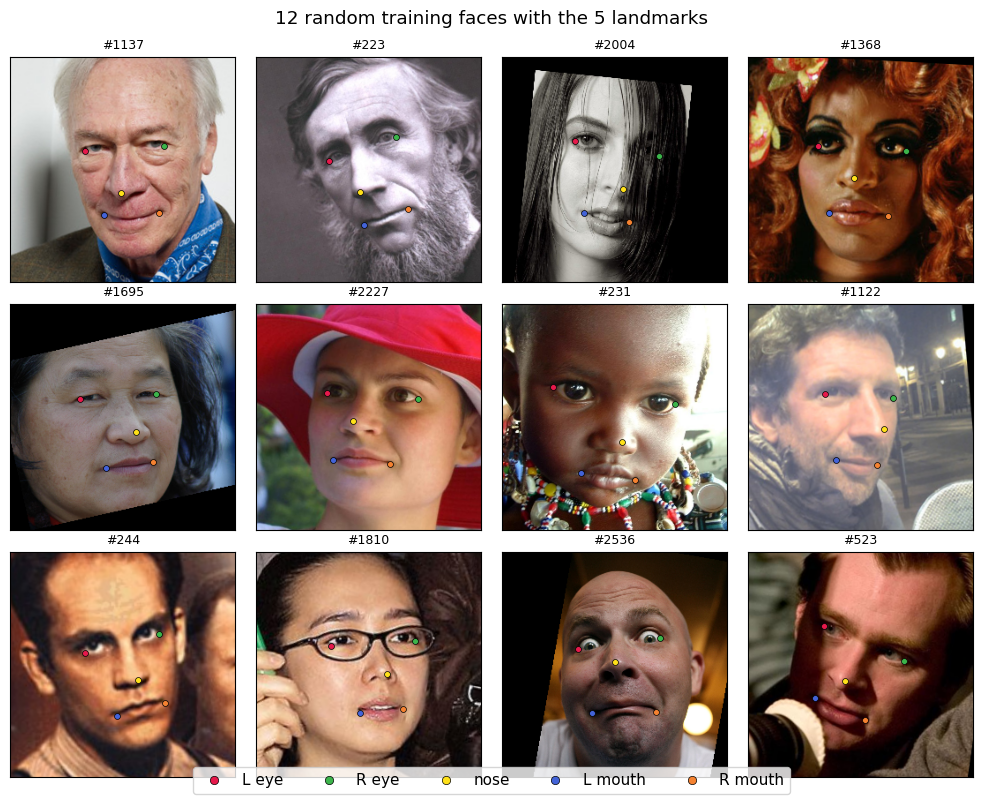

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/sample_grid.png


In [7]:
LANDMARK_NAMES = ['L eye', 'R eye', 'nose', 'L mouth', 'R mouth']
LANDMARK_COLOURS = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231']

def show_face(ax, img, pts=None, title=None):
    if img.ndim == 2 or (img.ndim == 3 and img.shape[-1] == 1):
        ax.imshow(np.squeeze(img), cmap='gray')
    else:
        ax.imshow(img.astype(np.uint8) if img.dtype != np.uint8 else img)
    if pts is not None:
        for k in range(pts.shape[0]):
            ax.scatter(pts[k, 0], pts[k, 1], c=LANDMARK_COLOURS[k], s=18,
                       edgecolors='black', linewidths=0.5, label=LANDMARK_NAMES[k])
    if title:
        ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

if train_images is not None:
    rng = np.random.default_rng(SEED)
    idx = rng.choice(train_images.shape[0], size=12, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(10, 8))
    for ax, i in zip(axes.ravel(), idx):
        show_face(ax, train_images[i], train_points[i], title=f'#{i}')
    handles = [plt.Line2D([0], [0], marker='o', linestyle='', color=c, label=n,
                          markeredgecolor='black', markeredgewidth=0.5)
               for c, n in zip(LANDMARK_COLOURS, LANDMARK_NAMES)]
    fig.legend(handles=handles, ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.01))
    fig.suptitle('12 random training faces with the 5 landmarks')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'sample_grid.png', bbox_inches='tight')
    plt.show()
    print('saved', FIG_DIR / 'sample_grid.png')

In [8]:
# Per-landmark mean / std in pixel coords.
if train_points is not None:
    mu  = np.nanmean(train_points, axis=0)
    sig = np.nanstd(train_points, axis=0)
    print(f'{"landmark":10s}  mean_x   mean_y    std_x   std_y')
    for k, name in enumerate(LANDMARK_NAMES):
        print(f'{name:10s} {mu[k,0]:7.2f} {mu[k,1]:7.2f}  {sig[k,0]:7.2f} {sig[k,1]:7.2f}')
    print('\nComment: mouth corners typically vary more than eyes; nose is usually the most stable.')

landmark    mean_x   mean_y    std_x   std_y
L eye        79.92  104.25     6.73    9.24
R eye       176.20  103.14     6.94    9.22
nose        128.65  142.60    13.59   10.35
L mouth      98.60  177.07    12.83    8.86
R mouth     159.61  176.15    12.55    9.24

Comment: mouth corners typically vary more than eyes; nose is usually the most stable.


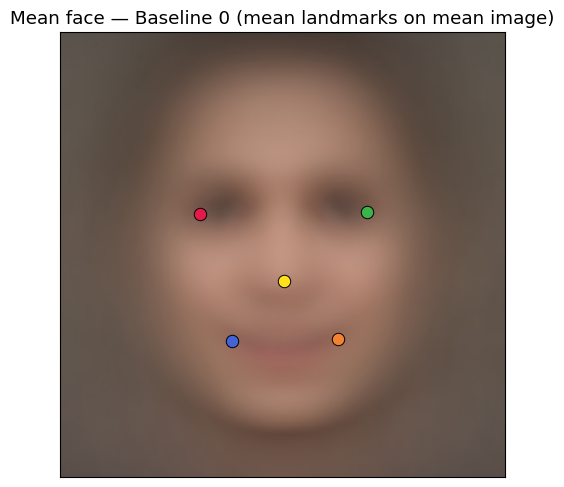

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/mean_face.png


In [9]:
# Mean face: mean landmarks overlaid on per-pixel mean image. The 0-component PCA shape model (W09_L18).
if train_images is not None:
    mean_img = train_images.astype(np.float64).mean(axis=0)
    mean_pts = np.nanmean(train_points, axis=0)
    fig, ax = plt.subplots(figsize=(5, 5))
    if mean_img.ndim == 2 or (mean_img.ndim == 3 and mean_img.shape[-1] == 1):
        ax.imshow(np.squeeze(mean_img), cmap='gray')
    else:
        ax.imshow(np.clip(mean_img, 0, 255).astype(np.uint8))
    for k in range(5):
        ax.scatter(mean_pts[k, 0], mean_pts[k, 1], c=LANDMARK_COLOURS[k], s=80,
                   edgecolors='black', linewidths=0.7)
    ax.set_title('Mean face — Baseline 0 (mean landmarks on mean image)')
    ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'mean_face.png', bbox_inches='tight')
    plt.show()
    print('saved', FIG_DIR / 'mean_face.png')

## 4. Variability assessment — what twist is the assignment testing?

The brief explicitly warns there is *variability — likely transformations that distort the images*. Quantify it before deciding which lectures' techniques to lean on.

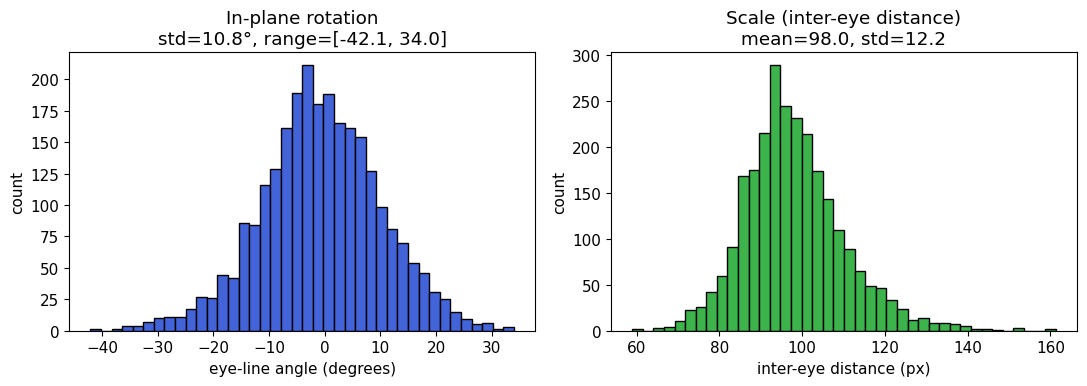

rotation: std=10.8°  -> WIDE in-plane spread
scale:    cv = std/mean = 0.12


In [10]:
if train_points is not None:
    # In-plane rotation: angle of the eye-to-eye line in degrees.
    dx = train_points[:, 1, 0] - train_points[:, 0, 0]
    dy = train_points[:, 1, 1] - train_points[:, 0, 1]
    eye_angle_deg = np.degrees(np.arctan2(dy, dx))

    # Inter-eye distance — scale proxy.
    inter_eye = np.sqrt(dx**2 + dy**2)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(eye_angle_deg, bins=40, color='#4363d8', edgecolor='black')
    axes[0].set_xlabel('eye-line angle (degrees)')
    axes[0].set_ylabel('count')
    axes[0].set_title(f'In-plane rotation\nstd={np.nanstd(eye_angle_deg):.1f}°, range=[{np.nanmin(eye_angle_deg):.1f}, {np.nanmax(eye_angle_deg):.1f}]')

    axes[1].hist(inter_eye, bins=40, color='#3cb44b', edgecolor='black')
    axes[1].set_xlabel('inter-eye distance (px)')
    axes[1].set_ylabel('count')
    axes[1].set_title(f'Scale (inter-eye distance)\nmean={np.nanmean(inter_eye):.1f}, std={np.nanstd(inter_eye):.1f}')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'variability_pose_scale.png', bbox_inches='tight')
    plt.show()
    print(f'rotation: std={np.nanstd(eye_angle_deg):.1f}°  -> {"WIDE" if np.nanstd(eye_angle_deg) > 10 else "narrow"} in-plane spread')
    print(f'scale:    cv = std/mean = {np.nanstd(inter_eye)/np.nanmean(inter_eye):.2f}')

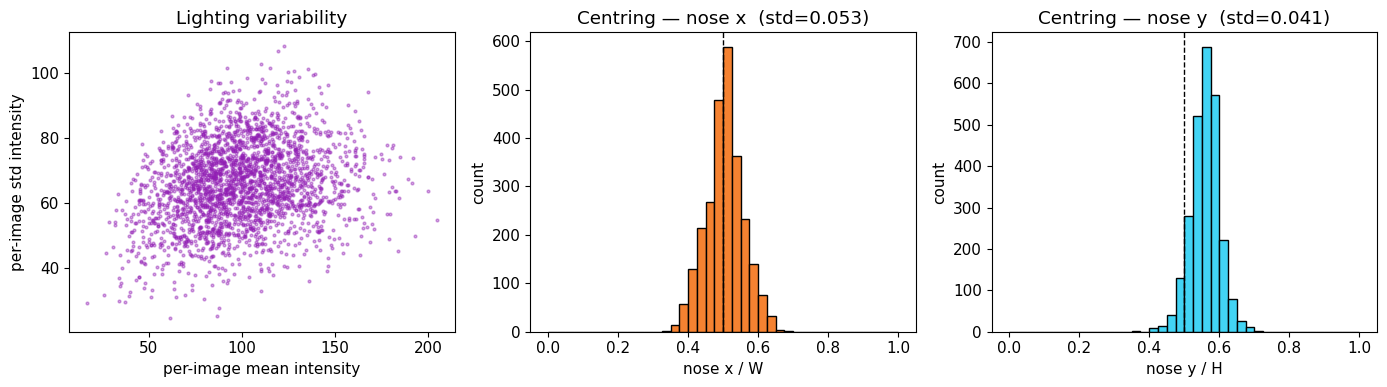

In [11]:
if train_images is not None:
    # Lighting: per-image intensity mean and std.
    flat = train_images.reshape(train_images.shape[0], -1).astype(np.float64)
    per_img_mean = flat.mean(axis=1)
    per_img_std  = flat.std(axis=1)

    # Centring: nose position normalised by (W, H).
    H = train_images.shape[1]; W = train_images.shape[2]
    nose_nx = train_points[:, 2, 0] / (W - 1)
    nose_ny = train_points[:, 2, 1] / (H - 1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].scatter(per_img_mean, per_img_std, s=4, alpha=0.4, color='#911eb4')
    axes[0].set_xlabel('per-image mean intensity')
    axes[0].set_ylabel('per-image std intensity')
    axes[0].set_title('Lighting variability')

    axes[1].hist(nose_nx, bins=40, range=(0, 1), color='#f58231', edgecolor='black')
    axes[1].axvline(0.5, color='black', ls='--', lw=1)
    axes[1].set_xlabel('nose x / W')
    axes[1].set_ylabel('count')
    axes[1].set_title(f'Centring — nose x  (std={np.nanstd(nose_nx):.3f})')

    axes[2].hist(nose_ny, bins=40, range=(0, 1), color='#42d4f4', edgecolor='black')
    axes[2].axvline(0.5, color='black', ls='--', lw=1)
    axes[2].set_xlabel('nose y / H')
    axes[2].set_ylabel('count')
    axes[2].set_title(f'Centring — nose y  (std={np.nanstd(nose_ny):.3f})')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'variability_lighting_centring.png', bbox_inches='tight')
    plt.show()

## 5. Train/validation split

The plan §4 says: use the supplied training set and build your own train/val split (`train_test_split`, `random_state=42`, `test_size=0.15`). Every downstream notebook loads `data/split_indices.npz`.

Note: the brief also supplies a *separate* validation set (`face_alignment_validation_data.npz`). We keep that as an additional held-out check — referenced via `data_layout.json` — but the modelling notebooks select hyper-parameters on the split below to keep things consistent with the plan.

In [12]:
if train_images is not None:
    idx_all = np.arange(train_images.shape[0])
    train_idx, val_idx = train_test_split(idx_all, test_size=0.15, random_state=SEED)
    np.savez(OUT_DATA_DIR / 'split_indices.npz', train_idx=train_idx, val_idx=val_idx)
    print(f'train={train_idx.size}  val={val_idx.size}  -> {OUT_DATA_DIR / "split_indices.npz"}')

train=2210  val=390  -> /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/data/split_indices.npz
